# Historical Destination Context — UN DESA Migrant Stock, 1990–2024

This notebook provides a complementary historical context for the destination analysis.

The main project focuses on the 2015–2024 analytical period. However, UN DESA provides longer historical reference years for migrant stock data.

This notebook uses UN DESA data to observe how the main destination countries of migrants originating from Cameroon evolved between 1990 and 2024.

This analysis is used only as historical background for Q1 and does not change the main analytical scope of the project.

## 1. Import Libraries

This section imports the main Python libraries used for the historical destination analysis.

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Define Project Paths

This section defines the main project paths.

The notebook loads UN DESA processed data and saves historical context uotputs in the 'outputs/' folder.

In [66]:
PROJECT_ROOT = Path("..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

GLOBAL_PATH = DATA_RAW / "global"
CLEANED_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned"
STANDARDIZED_PATH = PROJECT_ROOT / "data" / "processed" / "standardized"
OUTPUTS_PATH = PROJECT_ROOT / "outputs"
TABLES_PATH = OUTPUTS_PATH / "tables"
FIGURES_PATH = OUTPUTS_PATH / "figures"

CLEANED_PATH.mkdir(parents=True, exist_ok=True)

## 3. Load UN DESA Destination Data

This section loads the processed UN DESA destination dataset.

UN DESA is used because it provides a global view of migrant stock by origin and destination country across multiple historical reference years.

In [67]:
undesa = pd.read_csv(GLOBAL_PATH / "undesa_cameroon_global_destinations.csv")
undesa

,Destination,Location code of destination,Origin,Location code of origin,Year,Total,Male,Female
0,World,900,World,900,1990,153 916 063,77 772 082,76 143 981
1,World,900,Sub-Saharan Africa,1834,1990,14 124 662,7 458 958,6 665 704
2,World,900,Northern Africa and Western Asia,1833,1990,14 986 109,8 337 422,6 648 687
3,World,900,Central and Southern Asia,1831,1990,30 342 957,16 862 386,13 480 571
4,World,900,Eastern and South-Eastern Asia,1832,1990,14 465 509,7 069 837,7 395 672
...,...,...,...,...,...,...,...,...
224235,Wallis and Futuna Islands*,876,New Caledonia*,540,2024,1016,506,510
224236,Wallis and Futuna Islands*,876,Vanuatu,548,2024,67,39,28
224237,Wallis and Futuna Islands*,876,Polynesia*,957,2024,10,5,5
224238,Wallis and Futuna Islands*,876,French Polynesia*,258,2024,10,5,5


## 4. Inspect Data Structure

Before starting the historical analysis, we inspect the available columns and reference years.

In [68]:
undesa.columns.tolist()

['Destination',
 'Location code of destination',
 'Origin',
 'Location code of origin',
 'Year',
 'Total',
 'Male',
 'Female']

In [69]:
undesa = undesa[undesa["Origin"] == "Cameroon"].copy()
undesa

,Destination,Location code of destination,Origin,Location code of origin,Year,Total,Male,Female
49,World,900,Cameroon,120,1990,92 391,49 277,43 114
335,Sub-Saharan Africa,1834,Cameroon,120,1990,63 197,33 785,29 412
570,Northern Africa and Western Asia,1833,Cameroon,120,1990,65,51,14
765,Central and Southern Asia,1831,Cameroon,120,1990,..,..,..
914,Eastern and South-Eastern Asia,1832,Cameroon,120,1990,315,189,126
...,...,...,...,...,...,...,...,...
221814,NORTHERN AMERICA,905,Cameroon,120,2024,43 662,20 745,22 917
222076,Canada,124,Cameroon,120,2024,43 662,20 745,22 917
222421,OCEANIA,909,Cameroon,120,2024,695,397,298
222677,Australia/New Zealand,927,Cameroon,120,2024,695,397,298


In [70]:
for col in ["Total", "Male", "Female"]:
    undesa[col] = undesa[col].astype(str).str.replace(" ", "", regex=False)
    undesa[col] = pd.to_numeric(undesa[col], errors="coerce")
undesa

,Destination,Location code of destination,Origin,Location code of origin,Year,Total,Male,Female
49,World,900,Cameroon,120,1990,92391.0,49277.0,43114.0
335,Sub-Saharan Africa,1834,Cameroon,120,1990,63197.0,33785.0,29412.0
570,Northern Africa and Western Asia,1833,Cameroon,120,1990,65.0,51.0,14.0
765,Central and Southern Asia,1831,Cameroon,120,1990,NaN,NaN,NaN
914,Eastern and South-Eastern Asia,1832,Cameroon,120,1990,315.0,189.0,126.0
...,...,...,...,...,...,...,...,...
221814,NORTHERN AMERICA,905,Cameroon,120,2024,43662.0,20745.0,22917.0
222076,Canada,124,Cameroon,120,2024,43662.0,20745.0,22917.0
222421,OCEANIA,909,Cameroon,120,2024,695.0,397.0,298.0
222677,Australia/New Zealand,927,Cameroon,120,2024,695.0,397.0,298.0


Let us confirm whether the dataset includes the historical UN DESA reference years from 1990 to 2024.

In [71]:
sorted(undesa["Year"].unique())

[np.int64(1990),
 np.int64(1995),
 np.int64(2000),
 np.int64(2005),
 np.int64(2010),
 np.int64(2015),
 np.int64(2020),
 np.int64(2024)]

In [72]:
undesa["Destination"].nunique()

91

In [73]:
aggregates_to_remove = [
    "World",
    "More developed regions",
    "Less developed regions",
    "Less developed regions, excluding least developed countries",
    "Less developed regions, excluding China",

    "AFRICA",
    "ASIA",
    "EUROPE",
    "OCEANIA",
    "NORTHERN AMERICA",
    "LATIN AMERICA AND THE CARIBBEAN",

    "Africa",
    "Asia",
    "Europe and Northern America",
    "Latin America and the Caribbean",

    "Sub-Saharan Africa",
    "Northern Africa and Western Asia",
    "Central and Southern Asia",
    "Eastern and South-Eastern Asia",

    "Eastern Africa",
    "Middle Africa",
    "Northern Africa",
    "Southern Africa",
    "Western Africa",

    "Caribbean",
    "Central America",
    "South America",

    "Central Asia",
    "Eastern Asia",
    "Southern Asia",
    "South-Eastern Asia",
    "Western Asia",

    "Eastern Europe",
    "Northern Europe",
    "Southern Europe",
    "Western Europe",

    "Australia/New Zealand",
    "Oceania (excluding Australia and New Zealand)",
    "Melanesia",
    "Micronesia",
    "Polynesia*",

    "Least developed countries",
    "Land-locked Developing Countries (LLDC)",
    "Small Island Developing States (SIDS)",

    "Low-income countries",
    "Lower-middle-income countries",
    "Upper-middle-income countries",
    "High-income countries",
    "Middle-income countries",
    "Low-and-middle-income countries",
    "Low-and-Lower-middle-income countries",
    "High-and-upper-middle-income countries",
    "No income group available",
]

historical_destinations = undesa[
    ~undesa["Destination"].isin(aggregates_to_remove)
].copy()

historical_destinations


,Destination,Location code of destination,Origin,Location code of origin,Year,Total,Male,Female
7130,Zambia,894,Cameroon,120,1990,10.0,8.0,2.0
7467,Chad,148,Cameroon,120,1990,30992.0,16731.0,14261.0
7508,Congo,178,Cameroon,120,1990,3464.0,2036.0,1428.0
7583,Equatorial Guinea,226,Cameroon,120,1990,202.0,133.0,69.0
7620,Gabon,266,Cameroon,120,1990,15661.0,7765.0,7896.0
...,...,...,...,...,...,...,...,...
220610,Bolivia (Plurinational State of),68,Cameroon,120,2024,15.0,14.0,1.0
220828,Brazil,76,Cameroon,120,2024,723.0,532.0,191.0
220984,Chile,152,Cameroon,120,2024,281.0,49.0,232.0
222076,Canada,124,Cameroon,120,2024,43662.0,20745.0,22917.0


In [74]:
historical_destinations = undesa[
    ~undesa["Destination"].isin(aggregates_to_remove)
].copy()

historical_destinations = historical_destinations.rename(columns={
    "Destination": "destination_country",
    "Location code of destination": "destination_code",
    "Origin": "origin_country",
    "Location code of origin": "origin_code",
    "Year": "year",
    "Total": "total_migrants",
    "Male": "male_migrants",
    "Female": "female_migrants"
})
historical_destinations

,destination_country,destination_code,origin_country,origin_code,year,total_migrants,male_migrants,female_migrants
7130,Zambia,894,Cameroon,120,1990,10.0,8.0,2.0
7467,Chad,148,Cameroon,120,1990,30992.0,16731.0,14261.0
7508,Congo,178,Cameroon,120,1990,3464.0,2036.0,1428.0
7583,Equatorial Guinea,226,Cameroon,120,1990,202.0,133.0,69.0
7620,Gabon,266,Cameroon,120,1990,15661.0,7765.0,7896.0
...,...,...,...,...,...,...,...,...
220610,Bolivia (Plurinational State of),68,Cameroon,120,2024,15.0,14.0,1.0
220828,Brazil,76,Cameroon,120,2024,723.0,532.0,191.0
220984,Chile,152,Cameroon,120,2024,281.0,49.0,232.0
222076,Canada,124,Cameroon,120,2024,43662.0,20745.0,22917.0


In [75]:
historical_destinations["source"] = "UN DESA"
historical_destinations["dataset"] = "international_migrant_stock"
historical_destinations["measure_type"] = "stock"

historical_destinations

,destination_country,destination_code,origin_country,origin_code,year,total_migrants,male_migrants,female_migrants,source,dataset,measure_type
7130,Zambia,894,Cameroon,120,1990,10.0,8.0,2.0,UN DESA,international_migrant_stock,stock
7467,Chad,148,Cameroon,120,1990,30992.0,16731.0,14261.0,UN DESA,international_migrant_stock,stock
7508,Congo,178,Cameroon,120,1990,3464.0,2036.0,1428.0,UN DESA,international_migrant_stock,stock
7583,Equatorial Guinea,226,Cameroon,120,1990,202.0,133.0,69.0,UN DESA,international_migrant_stock,stock
7620,Gabon,266,Cameroon,120,1990,15661.0,7765.0,7896.0,UN DESA,international_migrant_stock,stock
...,...,...,...,...,...,...,...,...,...,...,...
220610,Bolivia (Plurinational State of),68,Cameroon,120,2024,15.0,14.0,1.0,UN DESA,international_migrant_stock,stock
220828,Brazil,76,Cameroon,120,2024,723.0,532.0,191.0,UN DESA,international_migrant_stock,stock
220984,Chile,152,Cameroon,120,2024,281.0,49.0,232.0,UN DESA,international_migrant_stock,stock
222076,Canada,124,Cameroon,120,2024,43662.0,20745.0,22917.0,UN DESA,international_migrant_stock,stock


In [76]:
historical_destinations.info()
historical_destinations.head()
historical_destinations.isna().sum()

<class 'pandas.DataFrame'>
Index: 376 entries, 7130 to 222928
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   destination_country  376 non-null    str    
 1   destination_code     376 non-null    int64  
 2   origin_country       376 non-null    str    
 3   origin_code          376 non-null    int64  
 4   year                 376 non-null    int64  
 5   total_migrants       350 non-null    float64
 6   male_migrants        349 non-null    float64
 7   female_migrants      322 non-null    float64
 8   source               376 non-null    str    
 9   dataset              376 non-null    str    
 10  measure_type         376 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 35.2 KB


destination_country     0
destination_code        0
origin_country          0
origin_code             0
year                    0
total_migrants         26
male_migrants          27
female_migrants        54
source                  0
dataset                 0
measure_type            0
dtype: int64

## 5. Prepare Historical Destination Data

This section prepares the UN DESA data for historical analysis.

The analysis focuses on migrant stock values by destination country and reference year.

Important methodological note:

UN DESA measures migrant stock, not migration inflows. Therefore, this notebook identifies where migrants originating from Cameroon were estimated to be living at each reference year, not how many people arrived during each period.

In [77]:
historical_destinations["year"] = pd.to_numeric(
    historical_destinations["year"],
    errors="coerce"
).astype("Int64")

# Use `value` when available, otherwise fall back to `total_migrants`
if "value" not in historical_destinations.columns and "total_migrants" in historical_destinations.columns:
    historical_destinations["value"] = historical_destinations["total_migrants"]

historical_destinations["value"] = pd.to_numeric(
    historical_destinations["value"],
    errors="coerce"
)

historical_destinations["destination_country"] = (
    historical_destinations["destination_country"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
)

historical_destinations = historical_destinations[
    historical_destinations["year"].between(1990, 2024)
].copy()

historical_destinations = historical_destinations[
    historical_destinations["destination_country"].notna()
].copy()

historical_destinations

,destination_country,destination_code,origin_country,origin_code,year,total_migrants,male_migrants,female_migrants,source,dataset,measure_type,value
7130,Zambia,894,Cameroon,120,1990,10.0,8.0,2.0,UN DESA,international_migrant_stock,stock,10.0
7467,Chad,148,Cameroon,120,1990,30992.0,16731.0,14261.0,UN DESA,international_migrant_stock,stock,30992.0
7508,Congo,178,Cameroon,120,1990,3464.0,2036.0,1428.0,UN DESA,international_migrant_stock,stock,3464.0
7583,Equatorial Guinea,226,Cameroon,120,1990,202.0,133.0,69.0,UN DESA,international_migrant_stock,stock,202.0
7620,Gabon,266,Cameroon,120,1990,15661.0,7765.0,7896.0,UN DESA,international_migrant_stock,stock,15661.0
...,...,...,...,...,...,...,...,...,...,...,...,...
220610,Bolivia (Plurinational State of),68,Cameroon,120,2024,15.0,14.0,1.0,UN DESA,international_migrant_stock,stock,15.0
220828,Brazil,76,Cameroon,120,2024,723.0,532.0,191.0,UN DESA,international_migrant_stock,stock,723.0
220984,Chile,152,Cameroon,120,2024,281.0,49.0,232.0,UN DESA,international_migrant_stock,stock,281.0
222076,Canada,124,Cameroon,120,2024,43662.0,20745.0,22917.0,UN DESA,international_migrant_stock,stock,43662.0


In [78]:
historical_destinations = historical_destinations.drop(columns=["destination_code", "origin_code"])
historical_destinations

,destination_country,origin_country,year,total_migrants,male_migrants,female_migrants,source,dataset,measure_type,value
7130,Zambia,Cameroon,1990,10.0,8.0,2.0,UN DESA,international_migrant_stock,stock,10.0
7467,Chad,Cameroon,1990,30992.0,16731.0,14261.0,UN DESA,international_migrant_stock,stock,30992.0
7508,Congo,Cameroon,1990,3464.0,2036.0,1428.0,UN DESA,international_migrant_stock,stock,3464.0
7583,Equatorial Guinea,Cameroon,1990,202.0,133.0,69.0,UN DESA,international_migrant_stock,stock,202.0
7620,Gabon,Cameroon,1990,15661.0,7765.0,7896.0,UN DESA,international_migrant_stock,stock,15661.0
...,...,...,...,...,...,...,...,...,...,...
220610,Bolivia (Plurinational State of),Cameroon,2024,15.0,14.0,1.0,UN DESA,international_migrant_stock,stock,15.0
220828,Brazil,Cameroon,2024,723.0,532.0,191.0,UN DESA,international_migrant_stock,stock,723.0
220984,Chile,Cameroon,2024,281.0,49.0,232.0,UN DESA,international_migrant_stock,stock,281.0
222076,Canada,Cameroon,2024,43662.0,20745.0,22917.0,UN DESA,international_migrant_stock,stock,43662.0


## 6. Validate Historical Dataset

This section checks the final historical dataset used for the analysis.

In [79]:
print("Shape:", historical_destinations.shape)
print("Years:", sorted(historical_destinations["year"].dropna().unique()))
print("Missing values:", historical_destinations["value"].isna().sum())
print("Number of destination countries:", historical_destinations["destination_country"].nunique())

Shape: (376, 10)
Years: [np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2024)]
Missing values: 26
Number of destination countries: 47


## 7. Top Destination Countries in 1990 and 2024

This section compares the top destination countries at the beginning and at the end of the available historical period.

The objective is to observe whether the main destination countries remained stable or changed over time.

In [82]:
top_destinations_historical = {}

for year in [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]:
    top_destinations_historical[year] = (
        historical_destinations[historical_destinations["year"] == year]
        .sort_values("value", ascending=False)
        .head(10)
        [["destination_country", "year", "value"]]
        .reset_index(drop=True)
    )
    
    print("=" * 70)
    print(f"Top 10 destination countries — {year}")
    print("=" * 70)
    display(top_destinations_historical[year])

Top 10 destination countries — 1990


,destination_country,year,value
0,Chad,1990,30992.0
1,France,1990,26305.0
2,Gabon,1990,15661.0
3,Nigeria,1990,10242.0
4,Congo,1990,3464.0
5,Belgium,1990,842.0
6,Senegal,1990,837.0
7,Italy,1990,747.0
8,Mali,1990,592.0
9,Mauritania,1990,350.0


Top 10 destination countries — 1995


,destination_country,year,value
0,Chad,1995,33673.0
1,France,1995,31718.0
2,Gabon,1995,20944.0
3,Nigeria,1995,10384.0
4,Congo,1995,4003.0
5,Belgium,1995,1327.0
6,Italy,1995,1258.0
7,Senegal,1995,875.0
8,Canada,1995,634.0
9,Mali,1995,618.0


Top 10 destination countries — 2000


...

,destination_country,year,value
0,France,2015,97288.0
1,Gabon,2015,46269.0
2,Chad,2015,30702.0
3,Nigeria,2015,26893.0
4,Canada,2015,18062.0
5,Belgium,2015,16560.0
6,Congo,2015,11300.0
7,Italy,2015,10856.0
8,South Africa,2015,5747.0
9,Mali,2015,1778.0


Top 10 destination countries — 2020


,destination_country,year,value
0,France,2020,114528.0
1,Nigeria,2020,52489.0
2,Gabon,2020,50906.0
3,Chad,2020,35635.0
4,Canada,2020,27172.0
5,Belgium,2020,22683.0
6,Italy,2020,15250.0
7,Congo,2020,11225.0
8,South Africa,2020,6112.0
9,Mali,2020,2084.0


Top 10 destination countries — 2024


,destination_country,year,value
0,France,2024,127995.0
1,Nigeria,2024,56288.0
2,Gabon,2024,54949.0
3,Canada,2024,43662.0
4,Chad,2024,40472.0
5,Belgium,2024,30634.0
6,Italy,2024,16244.0
7,Congo,2024,11167.0
8,South Africa,2024,4916.0
9,Mali,2024,2339.0


In [83]:
for year, table in top_destinations_historical.items():
    table = table.reset_index(drop=True)
    table.index = table.index + 1  # Start index at 1 instead of 0
    table.to_csv(
        TABLES_PATH / f"historical_top_10_destinations_{year}.csv",
        index=True
    )

## 8. Evolution of 2024 Top Destination Countries Since 1990

This section tracks the historical evolution of the top 10 destination countries observed in 2024.

The objective is to understand whether these destinations have been historically important or whether some of them became more significant over time.

In [84]:
top_2024_countries = (
    historical_destinations[historical_destinations["year"] == 2024]
    .sort_values("value", ascending=False)
    .head(10)["destination_country"]
    .tolist()
)

historical_top_2024_trend = (
    historical_destinations[
        historical_destinations["destination_country"].isin(top_2024_countries)
    ]
    .pivot_table(
        index="year",
        columns="destination_country",
        values="value",
        aggfunc="sum"
    )
    .sort_index()
)

historical_top_2024_trend

destination_country,Belgium,Canada,Chad,Congo,France,Gabon,Italy,Mali,Nigeria,South Africa
year,,,,,,,,,,
1990,842.0,238.0,30992.0,3464.0,26305.0,15661.0,747.0,592.0,10242.0,12.0
1995,1327.0,634.0,33673.0,4003.0,31718.0,20944.0,1258.0,618.0,10384.0,14.0
2000,2083.0,1498.0,36353.0,5614.0,41280.0,26199.0,2035.0,567.0,10943.0,843.0
2005,4532.0,2892.0,25161.0,3570.0,64858.0,28544.0,4460.0,2323.0,21748.0,3315.0
2010,10906.0,7697.0,29798.0,8502.0,80804.0,33089.0,7727.0,1445.0,22214.0,4207.0
2015,16560.0,18062.0,30702.0,11300.0,97288.0,46269.0,10856.0,1778.0,26893.0,5747.0
2020,22683.0,27172.0,35635.0,11225.0,114528.0,50906.0,15250.0,2084.0,52489.0,6112.0
2024,30634.0,43662.0,40472.0,11167.0,127995.0,54949.0,16244.0,2339.0,56288.0,4916.0


## 9. Historical Trend of 2024 Top Destination Countries

This chart shows how the current top destination countries evolved across UN DESA historical reference years.

It helps distinguish long-standing destination countries from more recent or emerging destinations.

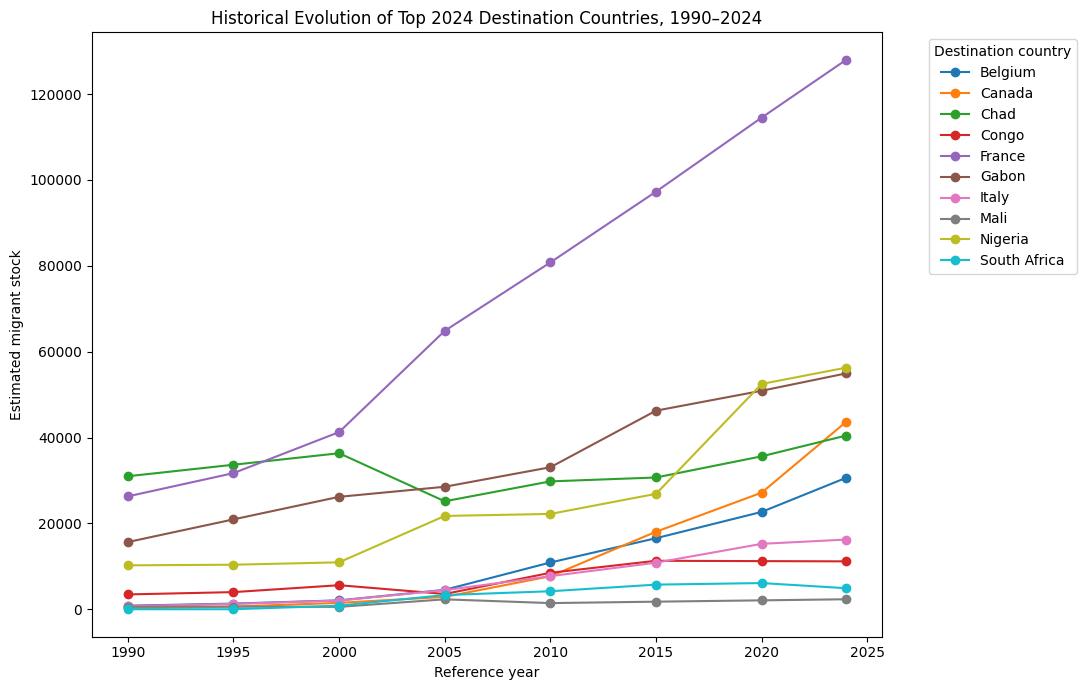

In [85]:
plt.figure(figsize=(11, 7))

for country in historical_top_2024_trend.columns:
    plt.plot(
        historical_top_2024_trend.index,
        historical_top_2024_trend[country],
        marker="o",
        label=country
    )

plt.title("Historical Evolution of Top 2024 Destination Countries, 1990–2024")
plt.xlabel("Reference year")
plt.ylabel("Estimated migrant stock")
plt.legend(title="Destination country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "historical_destination_trends_top_2024_countries_1990_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Largest Absolute Increases Between 1990 and 2024

This section identifies destination countries with the largest absolute increase in estimated migrant stock between 1990 and 2024.

This does not measure arrivals. It measures the change in stock between two reference years.

In [86]:
historical_change = (
    historical_destinations[historical_destinations["year"].isin([1990, 2024])]
    .pivot_table(
        index="destination_country",
        columns="year",
        values="value",
        aggfunc="sum"
    )
    .dropna(subset=[1990, 2024])
)

historical_change["absolute_change_1990_2024"] = (
    historical_change[2024] - historical_change[1990]
)

top_historical_increases = (
    historical_change
    .reset_index()
    .sort_values("absolute_change_1990_2024", ascending=False)
    .head(10)
)

top_historical_increases

year,destination_country,1990,2024,absolute_change_1990_2024
18,France,26305.0,127995.0,101690.0
37,Nigeria,10242.0,56288.0,46046.0
5,Canada,238.0,43662.0,43424.0
19,Gabon,15661.0,54949.0,39288.0
1,Belgium,842.0,30634.0,29792.0
26,Italy,747.0,16244.0,15497.0
6,Chad,30992.0,40472.0,9480.0
9,Congo,3464.0,11167.0,7703.0
43,South Africa,12.0,4916.0,4904.0
11,Cyprus,14.0,2001.0,1987.0


In [87]:
top_historical_increases.to_csv(
    TABLES_PATH / "historical_top_destination_increases_1990_2024.csv",
    index=False
)

## 11. Visualize Largest Absolute Increases

This chart shows the destination countries with the largest absolute increase in estimated migrant stock between 1990 and 2024.

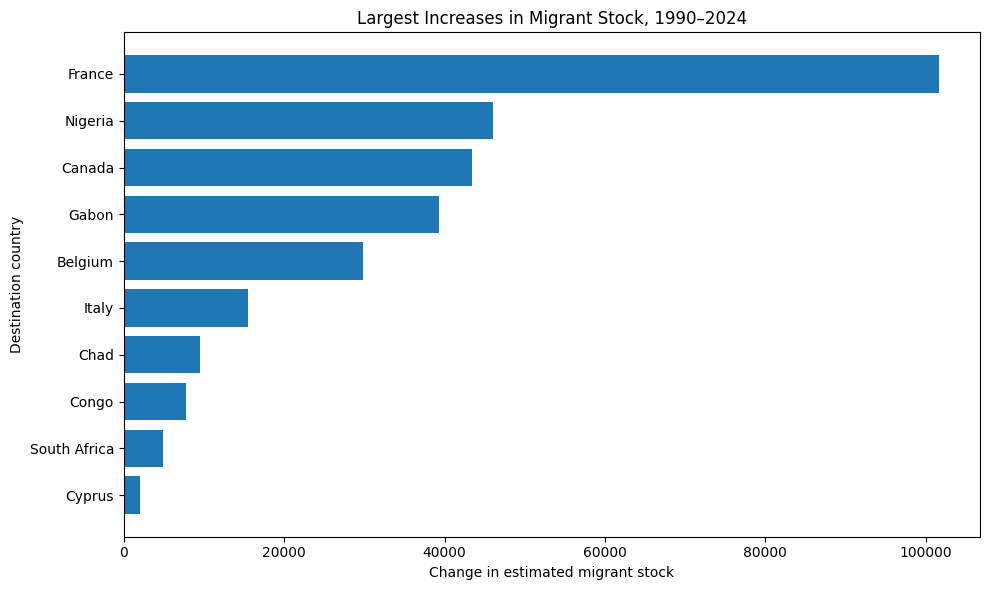

In [88]:
plot_data = top_historical_increases.sort_values(
    "absolute_change_1990_2024",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["destination_country"],
    plot_data["absolute_change_1990_2024"]
)

plt.title("Largest Increases in Migrant Stock, 1990–2024")
plt.xlabel("Change in estimated migrant stock")
plt.ylabel("Destination country")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "historical_largest_destination_increases_1990_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Concentration of Migrant Stock in Top 5 Destinations

This section measures the share of the total estimated migrant stock concentrated in the top 5 destination countries for each available reference year.

The objective is to understand whether Cameroonian migrant destinations became more concentrated or more diversified over time.

In [89]:
top5_share_by_year = []

for year in sorted(historical_destinations["year"].dropna().unique()):
    year_data = historical_destinations[historical_destinations["year"] == year].copy()
    
    total_stock = year_data["value"].sum()
    top5_stock = year_data.sort_values("value", ascending=False).head(5)["value"].sum()
    
    top5_share_by_year.append({
        "year": year,
        "total_stock": total_stock,
        "top5_stock": top5_stock,
        "top5_share_pct": top5_stock / total_stock * 100 if total_stock > 0 else None
    })

top5_share_by_year = pd.DataFrame(top5_share_by_year)

top5_share_by_year

,year,total_stock,top5_stock,top5_share_pct
0,1990,92391.0,86664.0,93.801344
1,1995,108473.0,100722.0,92.854443
2,2000,131985.0,120389.0,91.214153
3,2005,167265.0,144843.0,86.594924
4,2010,214405.0,176811.0,82.465894
5,2015,275824.0,219214.0,79.476043
6,2020,357087.0,280730.0,78.616696
7,2024,409677.0,323366.0,78.931939


## 13. Visualize Top 5 Destination Concentration

This chart shows whether the estimated migrant stock from Cameroon became more concentrated in the top destination countries over time.

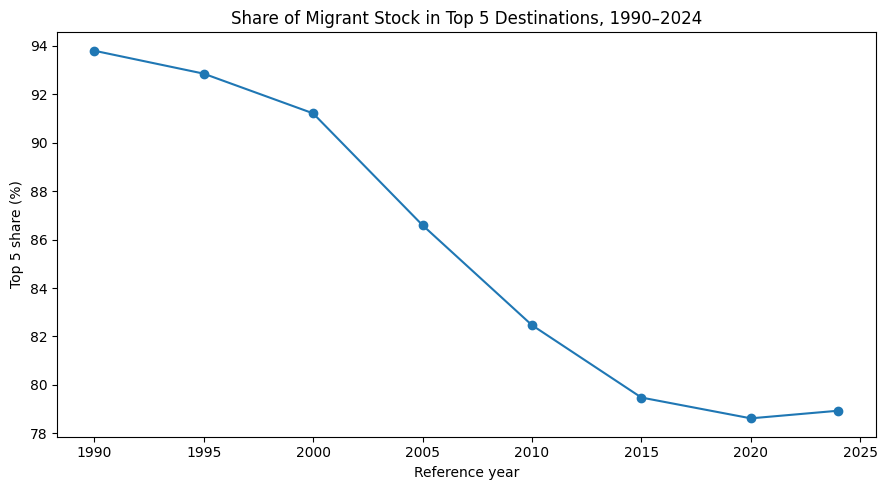

In [90]:
plt.figure(figsize=(9, 5))
plt.plot(
    top5_share_by_year["year"],
    top5_share_by_year["top5_share_pct"],
    marker="o"
)

plt.title("Share of Migrant Stock in Top 5 Destinations, 1990–2024")
plt.xlabel("Reference year")
plt.ylabel("Top 5 share (%)")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "historical_top5_destination_share_1990_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Historical Context Summary

This historical analysis provides additional background for Q1.

Key points:

- UN DESA allows the analysis of destination trends over a longer historical period, from 1990 to 2024.
- This historical view is limited to migrant stock by destination country.
- It should not be interpreted as migration arrivals or inflows.
- The main project scope remains focused on 2015–2024.
- The historical section helps contextualize whether major 2024 destination countries were already important in earlier reference years or became more significant over time.